# Aula 10: Treinando seu Próprio Detector YOLOv8 🚀

## 1. Configuração Inicial

In [1]:
from ultralytics import YOLO, settings
import os
import shutil
from IPython.display import Image, display

# Configurar pasta de saída local (para não salvar em /root/.config)
settings.update({'runs_dir': './runs'})

# Verificar se tem GPU (opcional, mas bom saber)
import torch
print(f"CUDA disponível? {torch.cuda.is_available()}")

CUDA disponível? False


## 2. Preparando o Dataset

In [2]:
dataset_path = 'dataset_academia/data.yaml'  

if not os.path.exists(dataset_path):
    print(f"⚠️ ATENÇÃO: Arquivo '{dataset_path}' não encontrado. Verifique o caminho!")
else:
    print(f"✅ Dataset encontrado: {dataset_path}")

✅ Dataset encontrado: dataset_academia/data.yaml


## 3. O Treinamento (Training) 🔥


In [3]:
# Carregar modelo pré-treinado
model = YOLO('yolov8n.pt')

# Iniciar treinamento
# Os resultados serão salvos em runs/detect/trainX
results = model.train(data=dataset_path, epochs=5, imgsz=416, batch=2)

Ultralytics 8.4.51  Python-3.11.9 torch-2.12.0+cpu CPU (Intel Core i5-7600K 3.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_academia/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

## 4. Analisando os Gráficos 📊

Resultados salvos em: C:\Users\pctri\trabalho-saulo\runs\detect\train-5


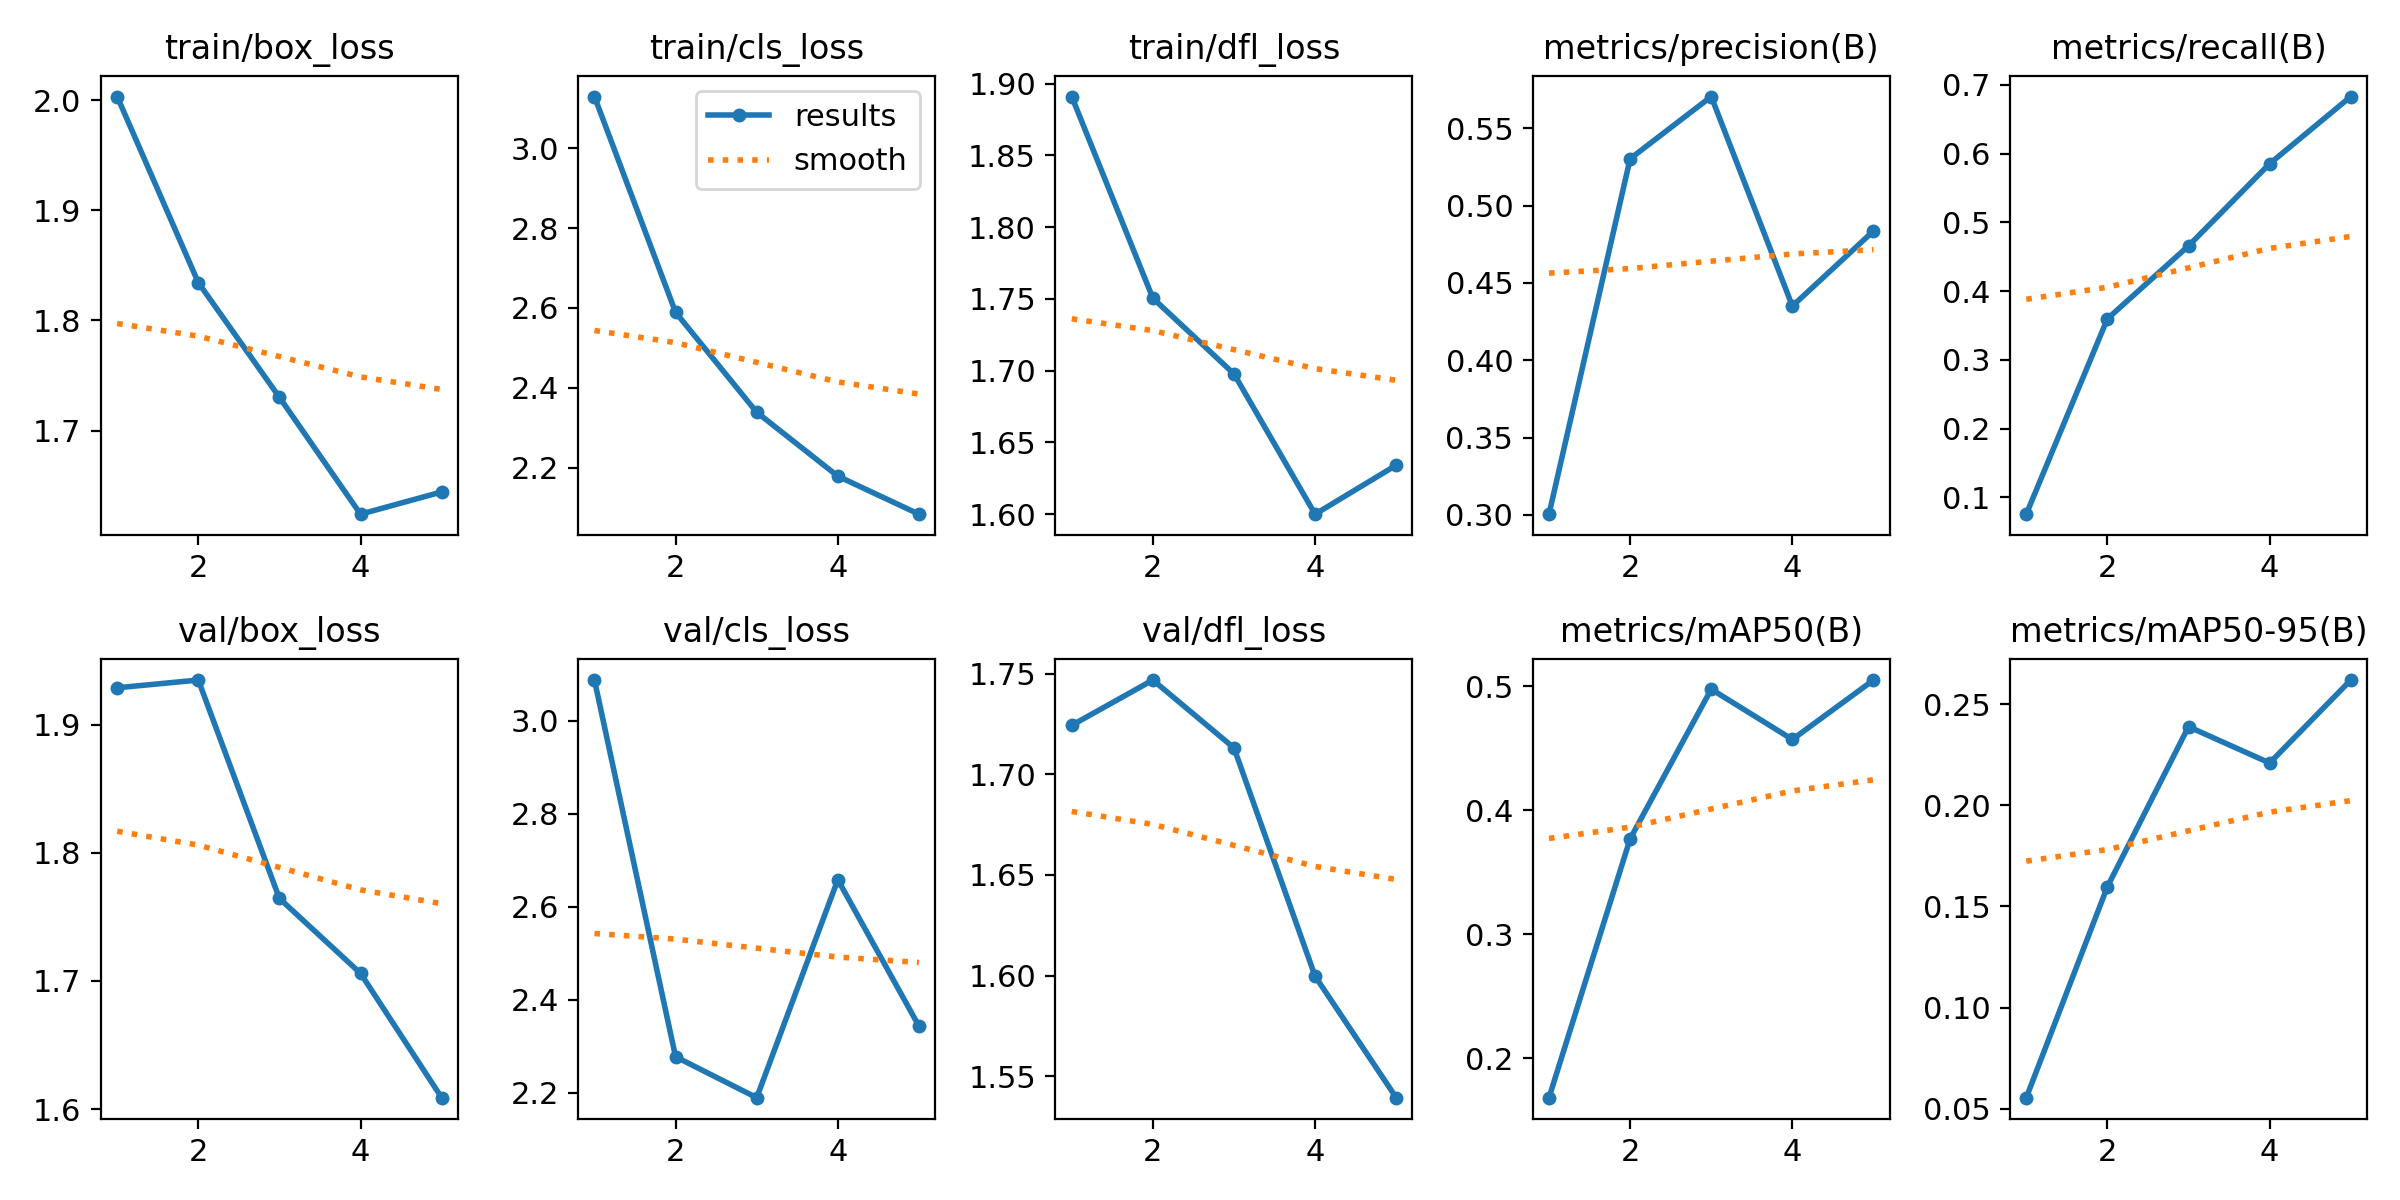

In [4]:
# O objeto 'results' guarda o diretório onde tudo foi salvo
print(f"Resultados salvos em: {results.save_dir}")

# Exibir os gráficos de perda e performance
Image(filename=f'{results.save_dir}/results.png')

## 5. Matriz de Confusão 😵

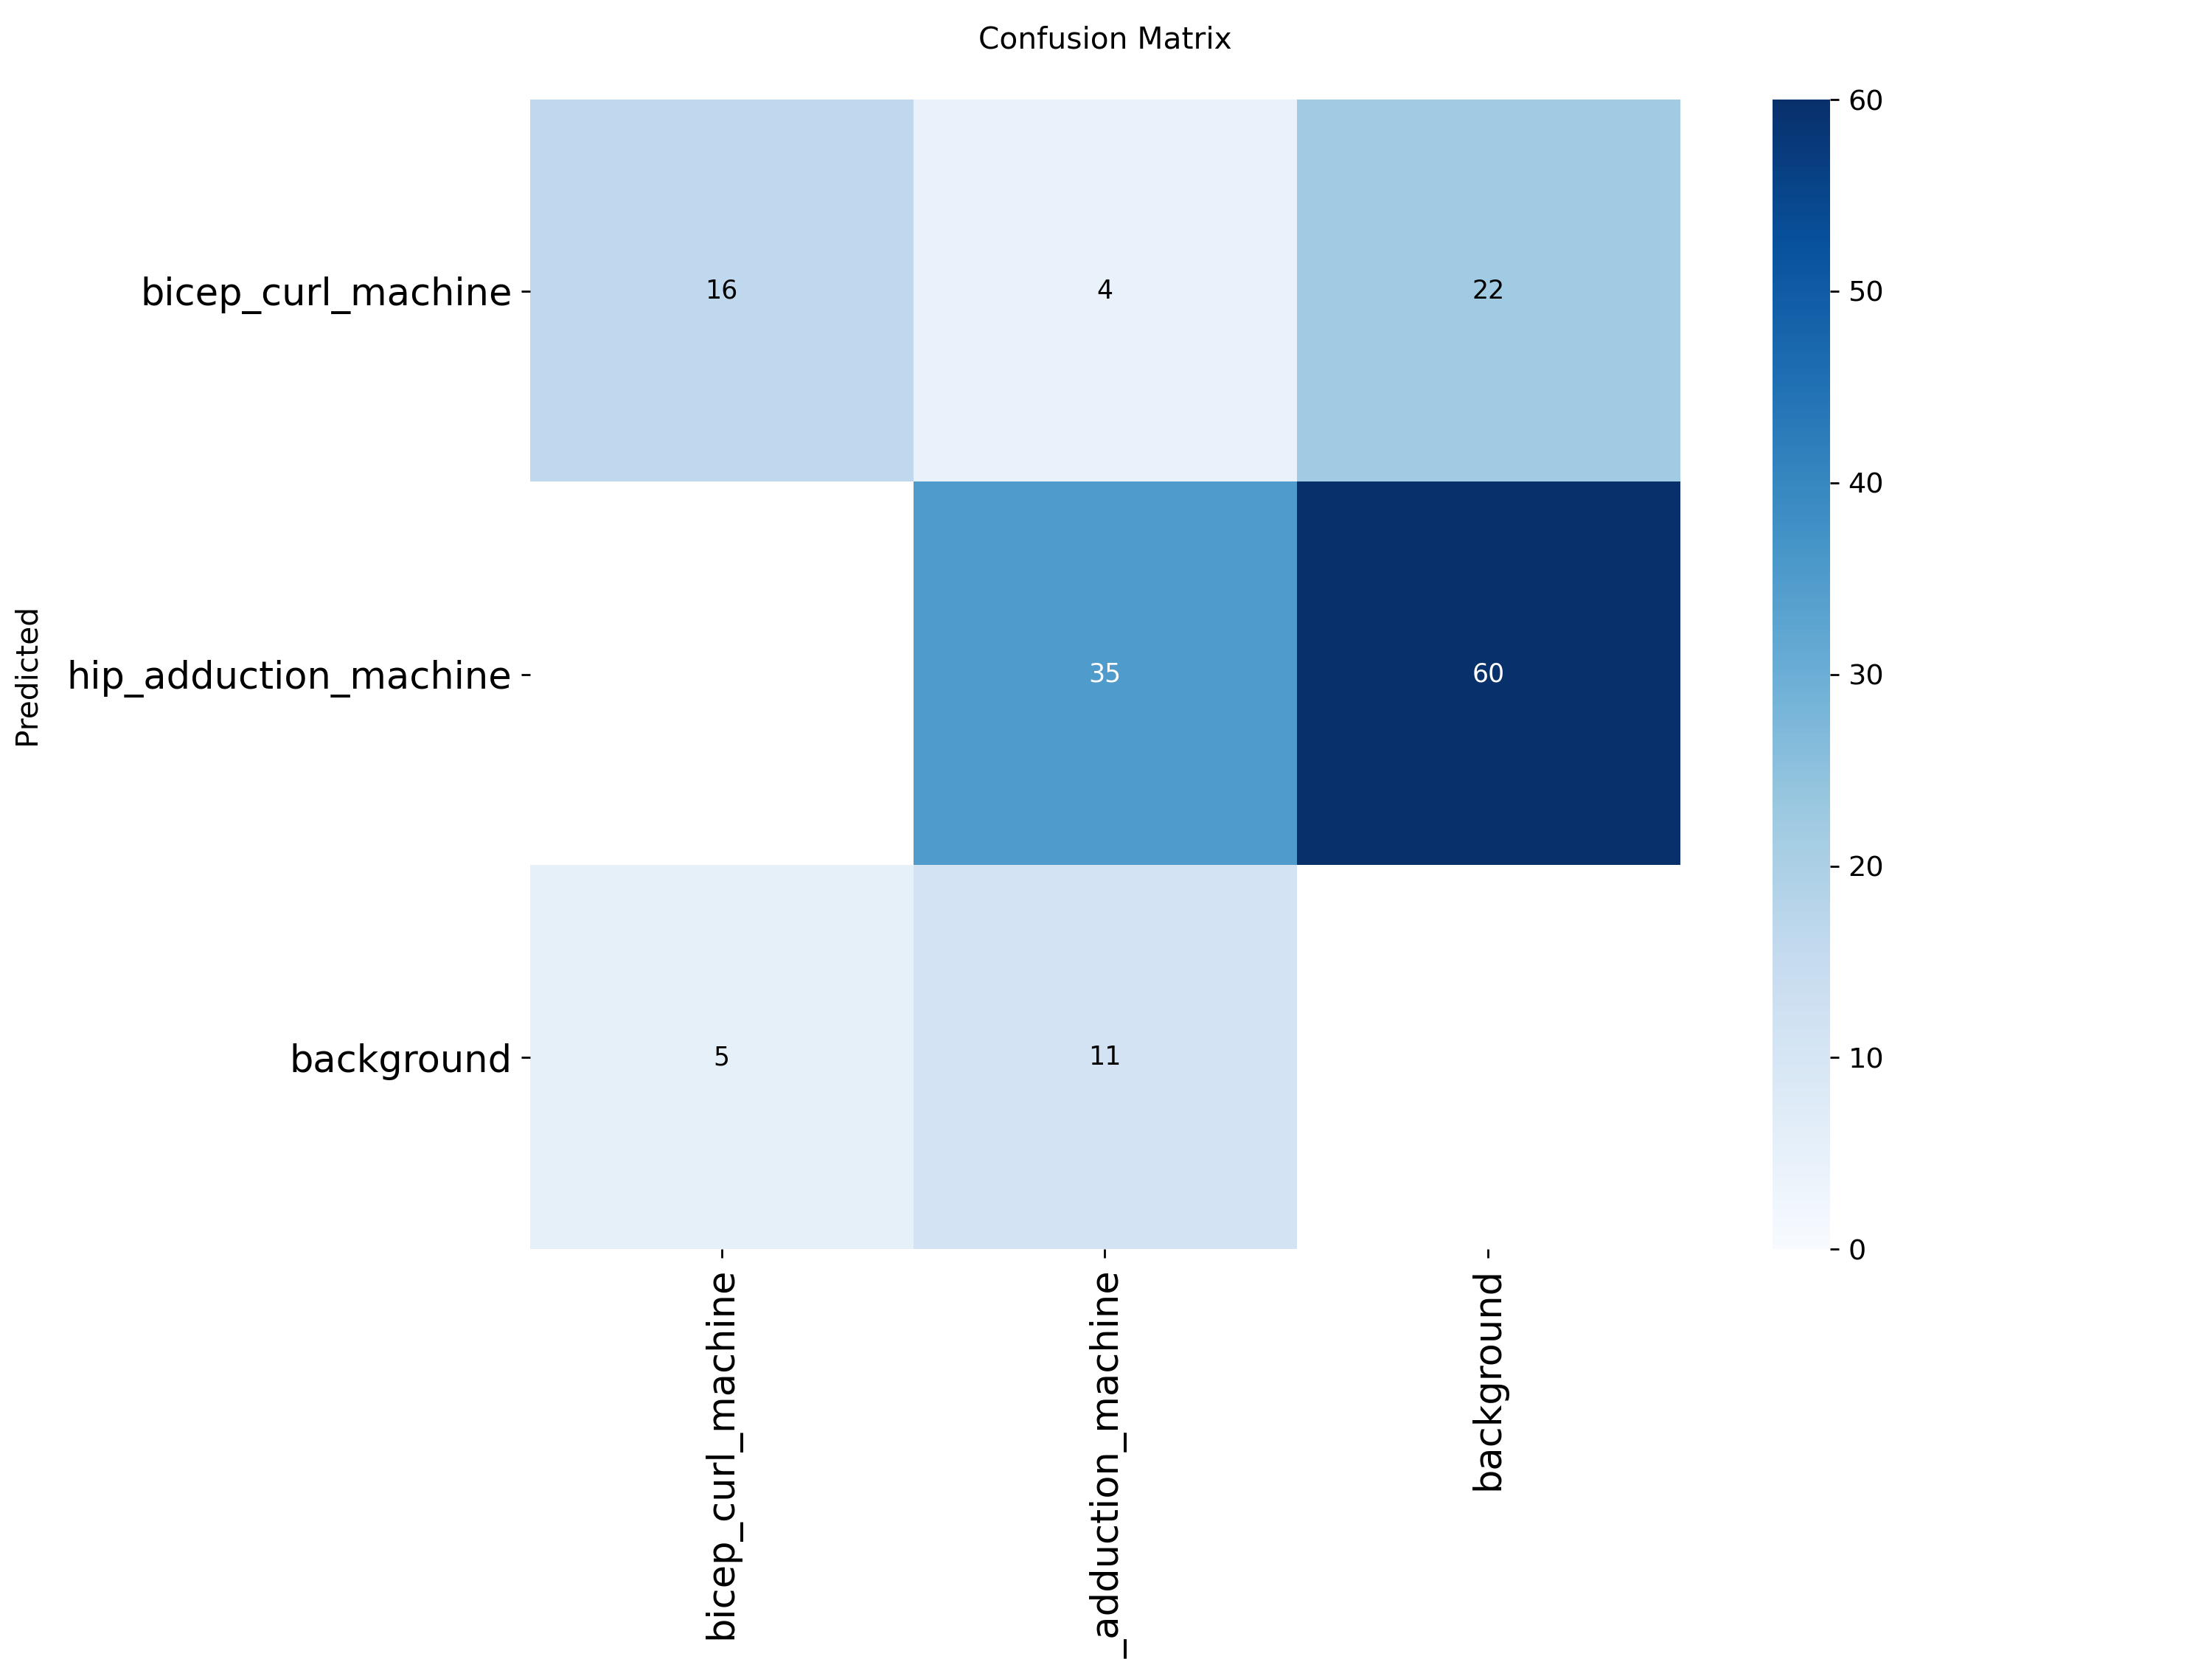

In [5]:
Image(filename=f'{results.save_dir}/confusion_matrix.png')

## 6. Validando em Imagens Reais (Inferência)

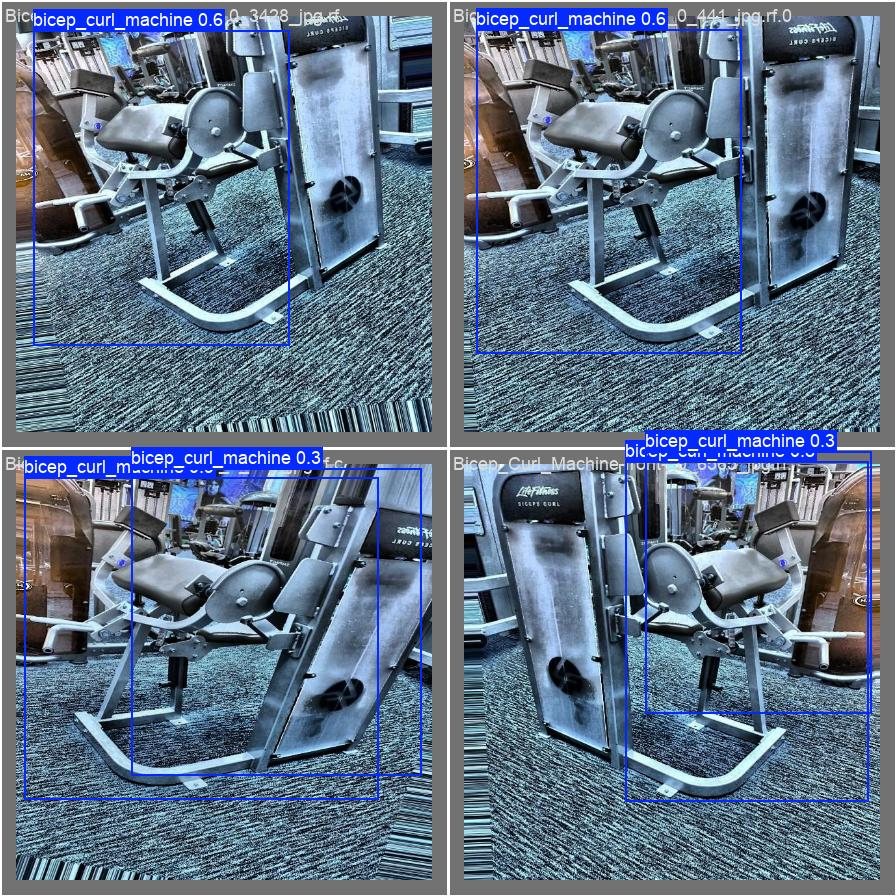

In [6]:
# O YOLO salva um lote de validação com as predições em 'val_batch0_pred.jpg'
Image(filename=f'{results.save_dir}/val_batch0_pred.jpg')